# Simulation

Minimal notebook for simulation-based distributional and tail-risk comparisons among Torri, Lo–Davis, and Vasicek models.

In [1]:
# =========================
# Setup
# =========================
SEED = 123

import random
import numpy as np
random.seed(SEED)
np.random.seed(SEED)

import math
import pandas as pd
import matplotlib.pyplot as plt

from math import lgamma
from scipy.optimize import minimize, brentq
from scipy.stats import norm, multivariate_normal
from numpy.polynomial.hermite import hermgauss

# ---- Optional: Japanese font for matplotlib ----
USE_JP_FONT = False
if USE_JP_FONT:
    import importlib.util
    if importlib.util.find_spec("japanize_matplotlib") is None:
        !pip install -q japanize-matplotlib
    import japanize_matplotlib  # noqa: F401

## Utilities

Numerical utilities and tail-risk functions.

In [12]:
# =========================
# Numeric utilities
# =========================

def log_comb(n: int, k: int) -> float:
    """log( n choose k )"""
    return lgamma(n+1) - lgamma(k+1) - lgamma(n-k+1)

def logsumexp_arr(logw: np.ndarray) -> float:
    """stable log(sum(exp(logw))) for 1D array"""
    m = np.max(logw)
    if np.isneginf(m):
        return -np.inf
    return m + np.log(np.sum(np.exp(logw - m)))

def logsumexp2(x: float, y: float) -> float:
    """log(exp(x)+exp(y))"""
    m = max(x, y)
    if np.isneginf(m):
        return -np.inf
    return m + np.log(np.exp(x-m) + np.exp(y-m))

def logsubexp(a: float, b: float) -> float:
    """log(exp(a)-exp(b)) with a>b; otherwise -inf"""
    if b >= a:
        return -np.inf
    return a + np.log1p(-np.exp(b - a))

def normalize_logpmf(logpmf: np.ndarray) -> np.ndarray:
    """Normalize log-PMF array to PMF (handles -inf safely)."""
    logpmf = np.where(np.isfinite(logpmf), logpmf, -np.inf)
    m = np.max(logpmf)
    if not np.isfinite(m):
        return np.full_like(logpmf, np.nan, dtype=float)
    z = np.sum(np.exp(logpmf - m))
    return np.exp(logpmf - (m + np.log(z)))

# =========================
# Tail & moments utilities
# =========================

def var_from_pmf(pmf: np.ndarray, alpha: float = 0.99, side: str = "left") -> int:
    """VaRα = inf{h: P(L<=h) >= α}."""
    cdf = np.cumsum(pmf)
    return int(np.searchsorted(cdf, alpha, side=side))

def es_from_pmf(pmf: np.ndarray, var_h: int, strict: bool = False) -> float:
    """
    ESα: default is E[L | L >= VaRα] (strict=False).
    strict=True -> E[L | L > VaRα]
    """
    pmf = np.asarray(pmf, dtype=float)
    x = np.arange(len(pmf))
    start = var_h + 1 if strict else var_h
    tail = pmf[start:]
    tp = tail.sum()
    if tp <= 0:
        return np.nan
    return float((x[start:] * tail).sum() / tp)

def moments_from_pmf(pmf: np.ndarray):
    x = np.arange(len(pmf))
    mean = float((x*pmf).sum())
    var = float(((x-mean)**2 * pmf).sum())
    return mean, var

def m_rho_from_pmf(pmf: np.ndarray):
    """Return (m, rho, Var(L)) where m=E[L]/n, rho is pairwise default corr (exchangeable proxy)."""
    pmf = np.asarray(pmf, dtype=float)
    s = pmf.sum()
    if s <= 0:
        return np.nan, np.nan, np.nan
    pmf = pmf / s

    n = len(pmf) - 1
    x = np.arange(n+1)

    EL  = float((x * pmf).sum())
    EL2 = float(((x**2) * pmf).sum())
    varL = EL2 - EL**2

    if n <= 0:
        return np.nan, np.nan, varL

    m = EL / n
    denom = n*(n-1)*m*(1-m)
    if denom <= 1e-15:
        return m, np.nan, varL

    rho = (varL - n*m*(1-m)) / denom
    return m, rho, varL

def survival_from_pmf(pmf: np.ndarray) -> np.ndarray:
    """S[h] = P(L >= h)"""
    return np.flip(np.cumsum(np.flip(pmf)))

def tail_metrics_from_pmf(pmf: np.ndarray, alpha: float = 0.99, strict_es: bool = False):
    v = var_from_pmf(pmf, alpha=alpha)
    e = es_from_pmf(pmf, v, strict=strict_es)
    return dict(
        VaR=v,
        ES=e,
        ES_minus_VaR=(e - v) if np.isfinite(e) else np.nan,
        ES_over_VaR=(e / v) if (np.isfinite(e) and v > 0) else np.nan
    )

## Torri model

Functions for the Torri infectious default model.

In [3]:
def pmf_Torri(n: int, p: float, u: float, v: float) -> np.ndarray:
    """
    Torri (infectious default) PMF for L_n.
    Numerically stable (log-sum-exp).
    """
    a = p*(1-v)
    b = (1-p)*(1-u)
    c = (1-p)*u
    bc = b + c  # = 1-p

    pmf_log = np.full(n+1, -np.inf, dtype=float)

    log_bc = -np.inf if bc <= 0 else np.log(bc)

    for h in range(n+1):
        # term0 = a^h * (b+c)^(n-h)
        if h == 0:
            log_a_h = 0.0
        else:
            log_a_h = -np.inf if a <= 0 else h*np.log(a)
        log_term0 = log_a_h + (n-h)*log_bc

        # term1 = ((p+b)^h - (a+b)^h) * c^(n-h)
        if h == 0:
            log_term1 = -np.inf
        else:
            # c^(n-h)
            if (n-h) == 0:
                log_c_pow = 0.0
            else:
                log_c_pow = -np.inf if c <= 0 else (n-h)*np.log(c)

            X = p + b
            Y = a + b

            if log_c_pow == -np.inf or X <= 0 or Y <= 0:
                log_term1 = -np.inf
            else:
                logXh = h*np.log(X)
                logYh = h*np.log(Y)
                log_diff = logsubexp(logXh, logYh)
                log_term1 = -np.inf if log_diff == -np.inf else (log_diff + log_c_pow)

        pmf_log[h] = log_comb(n, h) + logsumexp2(log_term0, log_term1)

    return normalize_logpmf(pmf_log)

def moments_from_params_Torri(n: int, p: float, u: float, v: float):
    """Closed-form (m, rho) for Torri parameterization used in this notebook."""
    b = (1-p)*(1-u)
    s = 1 - p*v

    # mean (fraction)
    m = p + b*(1 - s**(n-1))

    # pair moment term
    a_alt = s + p - 1
    s_pow = np.exp((n-2)*np.log(s)) if n > 2 else 1.0
    E = (p+b)**2 - b*(2*a_alt + b)*s_pow

    cov = E - m**2
    den = m*(1-m)
    rho = np.nan if den <= 1e-15 else cov/den
    return float(m), float(rho)

def find_params_on_iso_Torri(n: int, m_target: float, rho_target: float, p_grid: np.ndarray):
    """
    Solve (u,v) on iso-(m,rho) manifold by scanning p and solving for s.
    Returns list of dicts with keys: p,u,v,s,b
    """
    sols = []

    def bisect_root(f, lo, hi, it=80):
        flo, fhi = f(lo), f(hi)
        if not (np.isfinite(flo) and np.isfinite(fhi)) or flo*fhi > 0:
            return None
        for _ in range(it):
            mid = 0.5*(lo+hi)
            fmid = f(mid)
            if not np.isfinite(fmid):
                mid = np.nextafter(mid, lo)
                fmid = f(mid)
                if not np.isfinite(fmid):
                    return None
            if flo*fmid <= 0:
                hi, fhi = mid, fmid
            else:
                lo, flo = mid, fmid
        return 0.5*(lo+hi)

    for p in p_grid:
        if not (0 < p < m_target):
            continue

        s_lo = (1 - p) + 1e-10
        s_hi = 1 - 1e-10
        if s_lo >= s_hi:
            continue

        def b_of_s(s):
            denom = 1 - s**(n-1)
            if denom <= 0:
                return np.nan
            return (m_target - p) / denom

        def F(s):
            b = b_of_s(s)
            if not np.isfinite(b):
                return np.nan
            if not (0 <= b <= 1-p + 1e-12):
                return np.nan

            a_alt = s + p - 1
            s_pow = np.exp((n-2)*np.log(s)) if n > 2 else 1.0

            E = (p+b)**2 - b*(2*a_alt + b)*s_pow
            cov = E - (m_target**2)
            den = m_target*(1-m_target)
            rho = cov/den if den > 1e-15 else np.nan
            return rho - rho_target

        S = np.linspace(s_lo, s_hi, 600)
        Fv = np.array([F(s) for s in S])

        for k in range(len(S)-1):
            f1, f2 = Fv[k], Fv[k+1]
            if not (np.isfinite(f1) and np.isfinite(f2)):
                continue
            if f1 == 0:
                s_star = S[k]
            elif f1*f2 < 0:
                s_star = bisect_root(F, S[k], S[k+1])
                if s_star is None:
                    continue
            else:
                continue

            b = b_of_s(s_star)
            u = 1 - b/(1-p)
            v = (1 - s_star)/p
            if not (0 <= u <= 1 and 0 <= v <= 1):
                continue

            sols.append({"p": float(p), "u": float(u), "v": float(v),
                         "s": float(s_star), "b": float(b)})

    sols.sort(key=lambda d: d["p"])
    uniq = []
    for d in sols:
        if len(uniq) == 0:
            uniq.append(d); continue
        e = uniq[-1]
        if abs(d["u"]-e["u"]) + abs(d["v"]-e["v"]) > 5e-4:
            uniq.append(d)
    return uniq

In [7]:
# =========================
# Check consistency:
# closed-form moments vs PMF-implied moments (Torri)
# =========================
n=200

def check_torri_mrho_consistency(n: int, sols, atol_m: float = 1e-10, atol_rho: float = 1e-10):
    rows = []

    for i, sol in enumerate(sols):
        p = sol["p"]
        u = sol["u"]
        v = sol["v"]

        # closed-form
        m_cf, rho_cf = moments_from_params_Torri(n, p, u, v)

        # from PMF
        pmf = pmf_Torri(n, p, u, v)
        m_pmf, rho_pmf, varL_pmf = m_rho_from_pmf(pmf)

        rows.append({
            "idx": i,
            "p": p,
            "u": u,
            "v": v,
            "m_closed": m_cf,
            "m_pmf": m_pmf,
            "abs_err_m": abs(m_cf - m_pmf),
            "rho_closed": rho_cf,
            "rho_pmf": rho_pmf,
            "abs_err_rho": abs(rho_cf - rho_pmf),
            "ok_m": abs(m_cf - m_pmf) < atol_m,
            "ok_rho": abs(rho_cf - rho_pmf) < atol_rho,
            "pmf_sum": float(np.sum(pmf)),
            "varL_pmf": varL_pmf,
        })

    df_check = pd.DataFrame(rows)

    print("=== Torri consistency check ===")
    print(f"n = {n}, number of solutions = {len(df_check)}")
    if len(df_check) > 0:
        print("max |m_closed - m_pmf|   =", df_check["abs_err_m"].max())
        print("max |rho_closed - rho_pmf| =", df_check["abs_err_rho"].max())
        print("min/ max pmf_sum =", df_check["pmf_sum"].min(), df_check["pmf_sum"].max())

    return df_check


# ---- example ----
n=200
m_target=0.02
rho_target=0.08
# p は 0 < p < m_target の範囲で走査
p_grid = np.linspace(1e-4, m_target - 1e-4, 400)
sols = find_params_on_iso_Torri(n, m_target, rho_target, p_grid)

df_torri_check = check_torri_mrho_consistency(n, sols, atol_m=1e-10, atol_rho=1e-10)
df_torri_check.round(12)

df_torri_check.loc[~(df_torri_check["ok_m"] & df_torri_check["ok_rho"])].round(12)

=== Torri consistency check ===
n = 200, number of solutions = 321
max |m_closed - m_pmf|   = 3.6012859361278515e-15
max |rho_closed - rho_pmf| = 6.557254739192331e-14
min/ max pmf_sum = 0.9999999999999996 1.0000000000000004


,idx,p,u,v,m_closed,m_pmf,abs_err_m,rho_closed,rho_pmf,abs_err_rho,ok_m,ok_rho,pmf_sum,varL_pmf


## Lo–Davis model

Functions for the Lo–Davis cumulative contagion model.

In [8]:
def pmf_LD(n: int, p: float, q: float) -> np.ndarray:
    """
    Lo–Davis Infectious Default Model PMF via mixture:
      K ~ Bin(n,p), L|K=k = k + Bin(n-k, r_k), r_k = 1 - (1-q)^k
    Stable implementation using expm1/log1p and log-sum-exp.
    """
    if not (0.0 <= p <= 1.0 and 0.0 <= q <= 1.0):
        raise ValueError("p and q must be in [0,1].")

    # log P(K=k)
    logP_K = np.full(n+1, -np.inf, dtype=float)
    if p == 0.0:
        logP_K[0] = 0.0
    elif p == 1.0:
        logP_K[n] = 0.0
    else:
        log_p = np.log(p)
        log_1mp = np.log1p(-p)
        for k in range(n+1):
            logP_K[k] = log_comb(n, k) + k*log_p + (n-k)*log_1mp

    # r_k = 1 - (1-q)^k  (stable)
    r = np.zeros(n+1, dtype=float)
    if q == 0.0:
        r[:] = 0.0
    elif q == 1.0:
        r[0] = 0.0
        r[1:] = 1.0
    else:
        l = np.log1p(-q)
        ks = np.arange(n+1, dtype=float)
        r = -np.expm1(ks * l)

    pmf_log = np.full(n+1, -np.inf, dtype=float)

    for h in range(n+1):
        # sum over k=0..h
        terms = np.full(h+1, -np.inf, dtype=float)
        for k in range(h+1):
            if not np.isfinite(logP_K[k]):
                continue
            t = h - k
            nk = n - k
            rk = r[k]
            if t < 0 or t > nk:
                continue

            if rk == 0.0:
                if t != 0:
                    continue
                log_bin = 0.0
            elif rk == 1.0:
                if t != nk:
                    continue
                log_bin = 0.0
            else:
                log_rk = np.log(rk)
                log_1mrk = np.log1p(-rk)
                log_bin = log_comb(nk, t) + t*log_rk + (nk-t)*log_1mrk

            terms[k] = logP_K[k] + log_bin

        pmf_log[h] = logsumexp_arr(terms)

    return normalize_logpmf(pmf_log)

def m_rho_LD(n: int, p: float, q: float):
    """
    Closed-form (m, rhoZ) for Lo–Davis.
    m = 1 - (1-p)*(1-qp)^(n-1)
    Cov = (1-p)^2 * [ (1 - 2pq + p q^2)^(n-2) - (1-pq)^(2(n-1)) ]
    rho = Cov / (m(1-m))
    """
    m = 1.0 - (1.0 - p) * (1.0 - q*p)**(n-1)
    if n < 2:
        return float(m), np.nan
    termA = (1.0 - 2.0*p*q + p*(q**2))**(n-2)
    termB = (1.0 - p*q)**(2*(n-1))
    cov = (1.0 - p)**2 * (termA - termB)
    var = m*(1.0-m)
    rho = cov/var if var > 1e-15 else np.nan
    return float(m), float(rho)

def solve_pq_for_mrho_LD(n: int, m_target: float, rho_target: float,
                         p_bounds=(1e-10, 1-1e-10), q_bounds=(1e-10, 1-1e-10),
                         n_tries: int = 60, w_rho: float = 1.0):
    """Fit (p,q) to match (m_target, rho_target) by multi-start L-BFGS-B."""
    p_lo, p_hi = p_bounds
    q_lo, q_hi = q_bounds

    def objective(x):
        p, q = x
        if not (p_lo <= p <= p_hi and q_lo <= q <= q_hi):
            return 1e9
        m, rho = m_rho_LD(n, p, q)
        if not np.isfinite(m) or not np.isfinite(rho):
            return 1e9
        return (m - m_target)**2 + w_rho*(rho - rho_target)**2

    best = None
    rng = np.random.default_rng(SEED)

    init_list = [
        (min(max(m_target, p_lo), p_hi), 0.05),
        (0.01, 0.10), (0.05, 0.05), (0.10, 0.10), (0.30, 0.05), (0.50, 0.05),
    ]
    for _ in range(max(0, n_tries - len(init_list))):
        init_list.append((rng.uniform(p_lo, p_hi), rng.uniform(q_lo, q_hi)))

    for (p0, q0) in init_list:
        res = minimize(
            objective,
            x0=np.array([p0, q0], dtype=float),
            method="L-BFGS-B",
            bounds=[(p_lo, p_hi), (q_lo, q_hi)],
        )
        if not res.success:
            continue

        p_hat, q_hat = res.x
        m_hat, rho_hat = m_rho_LD(n, p_hat, q_hat)
        err_m = m_hat - m_target
        err_r = rho_hat - rho_target
        score = err_m**2 + w_rho*(err_r**2)

        cand = dict(
            p=float(p_hat), q=float(q_hat),
            m=float(m_hat), rho=float(rho_hat),
            err_m=float(err_m), err_rho=float(err_r),
            score=float(score), fun=float(res.fun),
            success=bool(res.success), message=str(res.message)
        )
        if (best is None) or (cand["score"] < best["score"]):
            best = cand

    if best is None:
        raise RuntimeError("最適化が収束しませんでした。(m, rho) が Lo–Davis で可到達か確認してください。")
    return best

def check_mrho_formula_vs_pmf_LD(n: int, p: float, q: float):
    pmf = pmf_LD(n, p, q)
    m_pmf, rho_pmf, _ = m_rho_from_pmf(pmf)
    m_f, rho_f = m_rho_LD(n, p, q)
    return dict(m_pmf=m_pmf, m_formula=m_f, diff_m=m_pmf-m_f,
                rho_pmf=rho_pmf, rho_formula=rho_f, diff_rho=rho_pmf-rho_f,
                pmf_sum=float(pmf.sum()))

In [9]:
# =========================
# Consistency check for Lo–Davis:
# closed-form moments vs PMF-implied moments
# =========================

def check_ld_mrho_consistency_one(n: int, p: float, q: float):
    out = check_mrho_formula_vs_pmf_LD(n, p, q)

    print("=== Lo–Davis consistency check (single parameter set) ===")
    print(f"n = {n}, p = {p:.12g}, q = {q:.12g}")
    print(f"m_formula = {out['m_formula']:.16e}")
    print(f"m_pmf     = {out['m_pmf']:.16e}")
    print(f"diff_m    = {out['diff_m']:.16e}")
    print(f"rho_formula = {out['rho_formula']:.16e}")
    print(f"rho_pmf     = {out['rho_pmf']:.16e}")
    print(f"diff_rho    = {out['diff_rho']:.16e}")
    print(f"pmf_sum     = {out['pmf_sum']:.16e}")

    return pd.DataFrame([out])


def check_ld_mrho_consistency_iso(
    n: int,
    m_target: float,
    rho_target: float,
    n_tries_list=(10, 20, 40, 80),
    atol_m: float = 1e-10,
    atol_rho: float = 1e-10,
):
    rows = []

    for nt in n_tries_list:
        sol = solve_pq_for_mrho_LD(
            n=n,
            m_target=m_target,
            rho_target=rho_target,
            n_tries=nt
        )

        chk = check_mrho_formula_vs_pmf_LD(n, sol["p"], sol["q"])

        rows.append({
            "n_tries": nt,
            "p": sol["p"],
            "q": sol["q"],
            "m_target": m_target,
            "rho_target": rho_target,
            "m_formula": chk["m_formula"],
            "m_pmf": chk["m_pmf"],
            "abs_err_m": abs(chk["diff_m"]),
            "rho_formula": chk["rho_formula"],
            "rho_pmf": chk["rho_pmf"],
            "abs_err_rho": abs(chk["diff_rho"]),
            "pmf_sum": chk["pmf_sum"],
            "fit_err_m": sol["err_m"],
            "fit_err_rho": sol["err_rho"],
            "score": sol["score"],
            "ok_m": abs(chk["diff_m"]) < atol_m,
            "ok_rho": abs(chk["diff_rho"]) < atol_rho,
        })

    df_check = pd.DataFrame(rows)

    print("=== Lo–Davis consistency check (multiple fitted parameter sets) ===")
    print(f"n = {n}, target m = {m_target}, target rho = {rho_target}")
    print("max |m_formula - m_pmf|   =", df_check["abs_err_m"].max())
    print("max |rho_formula - rho_pmf| =", df_check["abs_err_rho"].max())
    print("min/ max pmf_sum =", df_check["pmf_sum"].min(), df_check["pmf_sum"].max())

    return df_check


# ---- example 1: single fitted parameter set ----
best_ld = solve_pq_for_mrho_LD(n=200, m_target=0.02, rho_target=0.08, n_tries=60)
df_ld_one = check_ld_mrho_consistency_one(200, best_ld["p"], best_ld["q"])
df_ld_one.round(12)

=== Lo–Davis consistency check (single parameter set) ===
n = 200, p = 0.00124555118896, q = 0.0764748818212
m_formula = 1.9999946758648690e-02
m_pmf     = 1.9999946758637737e-02
diff_m    = -1.0953044027317560e-14
rho_formula = 8.0000023369925871e-02
rho_pmf     = 8.0000023369286730e-02
diff_rho    = -6.3914151748889481e-13
pmf_sum     = 1.0000000000000002e+00


,m_pmf,m_formula,diff_m,rho_pmf,rho_formula,diff_rho,pmf_sum
0,0.02,0.02,-0.0,0.08,0.08,-1.000000e-12,1.0


## Vasicek model

Functions for the one-factor Vasicek model.

In [11]:
def phi2_aa(a: float, rhoA: float) -> float:
    cov = np.array([[1.0, rhoA],
                    [rhoA, 1.0]])
    return float(multivariate_normal.cdf([a, a], mean=[0.0, 0.0], cov=cov))

def default_corr_from_asset_corr(m: float, rhoA: float) -> float:
    a = norm.ppf(m)
    q = phi2_aa(a, rhoA)
    return float((q - m*m) / (m*(1.0 - m)))

def invert_asset_corr_from_default_corr(m: float, rho_target: float, tol: float = 1e-10) -> float:
    """Solve rhoA in [0, 0.999999] such that Corr(Zi,Zj)=rho_target."""
    if not (0.0 < m < 1.0):
        raise ValueError("m must be in (0,1).")
    if not (-1.0 < rho_target < 1.0):
        raise ValueError("rho_target must be in (-1,1).")

    def F(rhoA):
        return default_corr_from_asset_corr(m, rhoA) - rho_target

    return float(brentq(F, 0.0, 0.999999, xtol=tol, rtol=tol, maxiter=200))

def pmf_Vas(n: int, m: float, rhoA: float, n_gh: int = 60) -> np.ndarray:
    """
    L|Y=y ~ Bin(n, p(y)), p(y)=Phi((a - sqrt(rhoA)*y)/sqrt(1-rhoA))
    PMF = E[ BinPMF(h; n, p(Y)) ] using Gauss-Hermite + log-sum-exp.
    """
    a = norm.ppf(m)
    s = np.sqrt(rhoA)
    t = np.sqrt(1.0 - rhoA)

    x, w = hermgauss(n_gh)
    y = np.sqrt(2.0) * x
    log_w = np.log(w) - 0.5*np.log(np.pi)

    p = norm.cdf((a - s*y) / t)
    p = np.clip(p, 1e-15, 1.0 - 1e-15)
    logp = np.log(p)
    log1mp = np.log1p(-p)

    hs = np.arange(n+1)
    logC = np.array([log_comb(n, h) for h in hs], dtype=float)

    log_bin = logC[None, :] + hs[None, :]*logp[:, None] + (n-hs)[None, :]*log1mp[:, None]
    log_terms = log_w[:, None] + log_bin

    m0 = np.max(log_terms, axis=0)
    pmf = np.exp(m0 + np.log(np.sum(np.exp(log_terms - m0[None, :]), axis=0)))

    pmf = np.maximum(pmf, 0.0)
    pmf = pmf / pmf.sum()
    return pmf

In [14]:
# =========================
# Consistency check for Vasicek
# closed-form (m, rho) vs PMF-implied (m, rho)
# using existing functions:
#   - default_corr_from_asset_corr
#   - invert_asset_corr_from_default_corr
#   - pmf_Vas
#   - m_rho_from_pmf
# =========================

def check_vas_mrho_consistency_one(n: int, m: float, rhoA: float, n_gh: int = 60):
    """
    Check one parameter set:
      closed-form (m, rho) vs PMF-implied (m, rho)
    """
    rho_closed = default_corr_from_asset_corr(m, rhoA)
    pmf = pmf_Vas(n, m, rhoA, n_gh=n_gh)
    m_pmf, rho_pmf, varL_pmf = m_rho_from_pmf(pmf)

    out = {
        "n": n,
        "m_input": float(m),
        "rhoA_input": float(rhoA),
        "rho_closed": float(rho_closed),
        "m_pmf": float(m_pmf),
        "rho_pmf": float(rho_pmf),
        "abs_err_m": abs(m_pmf - m),
        "abs_err_rho": abs(rho_pmf - rho_closed),
        "pmf_sum": float(np.sum(pmf)),
        "varL_pmf": float(varL_pmf),
        "n_gh": int(n_gh),
    }

    print("=== Vasicek consistency check (single parameter set) ===")
    print(f"n = {n}, m = {m:.12g}, rhoA = {rhoA:.12g}, n_gh = {n_gh}")
    print(f"rho_closed = {out['rho_closed']:.16e}")
    print(f"m_pmf      = {out['m_pmf']:.16e}")
    print(f"rho_pmf    = {out['rho_pmf']:.16e}")
    print(f"abs_err_m   = {out['abs_err_m']:.16e}")
    print(f"abs_err_rho = {out['abs_err_rho']:.16e}")
    print(f"pmf_sum     = {out['pmf_sum']:.16e}")

    return pd.DataFrame([out])


def check_vas_mrho_consistency_from_target(
    n: int,
    m_target: float,
    rho_target: float,
    n_gh_list=(20, 40, 60, 100, 200),
    atol_m: float = 1e-10,
    atol_rho: float = 1e-8,
):
    """
    Given target (m, rho), first invert rhoA, then compare:
      closed-form rho(m, rhoA) vs PMF-implied rho
    across different GH sizes.
    """
    rhoA = invert_asset_corr_from_default_corr(m_target, rho_target)

    rows = []
    for n_gh in n_gh_list:
        rho_closed = default_corr_from_asset_corr(m_target, rhoA)
        pmf = pmf_Vas(n, m_target, rhoA, n_gh=n_gh)
        m_pmf, rho_pmf, varL_pmf = m_rho_from_pmf(pmf)

        rows.append({
            "n": n,
            "m_target": float(m_target),
            "rho_target": float(rho_target),
            "rhoA_inverted": float(rhoA),
            "n_gh": int(n_gh),
            "rho_closed": float(rho_closed),
            "m_pmf": float(m_pmf),
            "rho_pmf": float(rho_pmf),
            "abs_err_m": abs(m_pmf - m_target),
            "abs_err_rho": abs(rho_pmf - rho_closed),
            "pmf_sum": float(np.sum(pmf)),
            "varL_pmf": float(varL_pmf),
            "ok_m": abs(m_pmf - m_target) < atol_m,
            "ok_rho": abs(rho_pmf - rho_closed) < atol_rho,
        })

    df_check = pd.DataFrame(rows)

    print("=== Vasicek consistency check (target m, rho) ===")
    print(f"n = {n}, target m = {m_target}, target rho = {rho_target}")
    print(f"inverted rhoA = {rhoA:.16e}")
    print("max |m_target - m_pmf|   =", df_check["abs_err_m"].max())
    print("max |rho_closed - rho_pmf| =", df_check["abs_err_rho"].max())
    print("min/ max pmf_sum =", df_check["pmf_sum"].min(), df_check["pmf_sum"].max())

    return df_check


# ---- example 1: one parameter set ----
df_vas_one = check_vas_mrho_consistency_one(
    n=200,
    m=0.02,
    rhoA=0.3439,
    n_gh=60
)
df_vas_one.round(12)

=== Vasicek consistency check (single parameter set) ===
n = 200, m = 0.02, rhoA = 0.3439, n_gh = 60
rho_closed = 8.0006900506835357e-02
m_pmf      = 1.9999999999999594e-02
rho_pmf    = 8.0006900506836245e-02
abs_err_m   = 4.0592529337857286e-16
abs_err_rho = 8.8817841970012523e-16
pmf_sum     = 1.0000000000000002e+00


,n,m_input,rhoA_input,rho_closed,m_pmf,rho_pmf,abs_err_m,abs_err_rho,pmf_sum,varL_pmf,n_gh
0,200,0.02,0.3439,0.080007,0.02,0.080007,0.0,0.0,1.0,66.331783,60


## Comparison on an iso-*(m, rho)* manifold

Set target mean default rate and pairwise correlation, then compare model-implied loss distributions.

In [13]:
# -------------------------
# Config
# -------------------------
n = 200
m_target = 0.02
rho_target = 0.08
alpha = 0.99
strict_es = False  # ES = E[L | L >= VaR] by default

# -------------------------
# Torri: scan p and solve
# -------------------------
p_grid = np.linspace(0.001, m_target*0.999, 10)
sols_Torri = find_params_on_iso_Torri(n, m_target, rho_target, p_grid)

# -------------------------
# Lo–Davis: fit (p,q)
# -------------------------
sol_LD = solve_pq_for_mrho_LD(n=n, m_target=m_target, rho_target=rho_target, n_tries=60, w_rho=1.0)
pmf_ld = pmf_LD(n, sol_LD["p"], sol_LD["q"])

# -------------------------
# Vasicek: implied asset corr
# -------------------------
rhoA_hat = invert_asset_corr_from_default_corr(m_target, rho_target)
pmf_vas = pmf_Vas(n, m_target, rhoA_hat, n_gh=60)

# -------------------------
# Summary table: VaR/ES and (m,rho) checks
# -------------------------
rows = []

for d in sols_Torri:
    pmf = pmf_Torri(n, d["p"], d["u"], d["v"])
    tm = tail_metrics_from_pmf(pmf, alpha=alpha, strict_es=strict_es)
    m_par, rho_par = moments_from_params_Torri(n, d["p"], d["u"], d["v"])
    m_pmf, rho_pmf, _ = m_rho_from_pmf(pmf)
    rows.append({
        "Model": "Torri",
        "p": d["p"], "u": d["u"], "v": d["v"],
        "q": np.nan, "rhoA": np.nan,
        "m_param": m_par, "rho_param": rho_par,
        "m_pmf": m_pmf, "rho_pmf": rho_pmf,
        "VaR99": tm["VaR"], "ES99": tm["ES"],
        "ES-VaR": tm["ES_minus_VaR"], "ES/VaR": tm["ES_over_VaR"],
    })

tm_ld = tail_metrics_from_pmf(pmf_ld, alpha=alpha, strict_es=strict_es)
m_ld, rho_ld, _ = m_rho_from_pmf(pmf_ld)
rows.append({
    "Model": "Lo–Davis",
    "p": sol_LD["p"], "u": np.nan, "v": np.nan,
    "q": sol_LD["q"], "rhoA": np.nan,
    "m_param": sol_LD["m"], "rho_param": sol_LD["rho"],
    "m_pmf": m_ld, "rho_pmf": rho_ld,
    "VaR99": tm_ld["VaR"], "ES99": tm_ld["ES"],
    "ES-VaR": tm_ld["ES_minus_VaR"], "ES/VaR": tm_ld["ES_over_VaR"],
})

tm_v = tail_metrics_from_pmf(pmf_vas, alpha=alpha, strict_es=strict_es)
m_v, rho_v, _ = m_rho_from_pmf(pmf_vas)
rows.append({
    "Model": "Vasicek",
    "p": m_target, "u": np.nan, "v": np.nan,
    "q": np.nan, "rhoA": rhoA_hat,
    "m_param": m_target, "rho_param": default_corr_from_asset_corr(m_target, rhoA_hat),
    "m_pmf": m_v, "rho_pmf": rho_v,
    "VaR99": tm_v["VaR"], "ES99": tm_v["ES"],
    "ES-VaR": tm_v["ES_minus_VaR"], "ES/VaR": tm_v["ES_over_VaR"],
})

df_summary = pd.DataFrame(rows)
df_summary = df_summary.sort_values(["Model","p"], na_position="last")

display(df_summary)

,Model,p,u,v,q,rhoA,m_param,rho_param,m_pmf,rho_pmf,VaR99,ES99,ES-VaR,ES/VaR
7,Lo–Davis,0.001246,NaN,NaN,0.076475,NaN,0.02,0.08,0.02,0.08,33,37.915134,4.915134,1.148943
0,Torri,0.003109,0.898636,0.295516,NaN,NaN,0.02,0.08,0.02,0.08,29,30.591544,1.591544,1.054881
1,Torri,0.005218,0.887343,0.136180,NaN,NaN,0.02,0.08,0.02,0.08,31,32.817221,1.817221,1.058620
2,Torri,0.007327,0.871519,0.071763,NaN,NaN,0.02,0.08,0.02,0.08,34,36.073926,2.073926,1.060998
3,Torri,0.009436,0.848454,0.038857,NaN,NaN,0.02,0.08,0.02,0.08,38,40.468458,2.468458,1.064959
4,Torri,0.011544,0.812739,0.020350,NaN,NaN,0.02,0.08,0.02,0.08,44,47.075229,3.075229,1.069892
5,Torri,0.013653,0.751775,0.009666,NaN,NaN,0.02,0.08,0.02,0.08,54,58.132238,4.132238,1.076523
6,Torri,0.015762,0.627897,0.003710,NaN,NaN,0.02,0.08,0.02,0.08,70,78.737869,8.737869,1.124827
8,Vasicek,0.020000,NaN,NaN,NaN,0.343882,0.02,0.08,0.02,0.08,40,55.817409,15.817409,1.395435


## PMF and survival comparison

Generate the main distributional comparison figure.

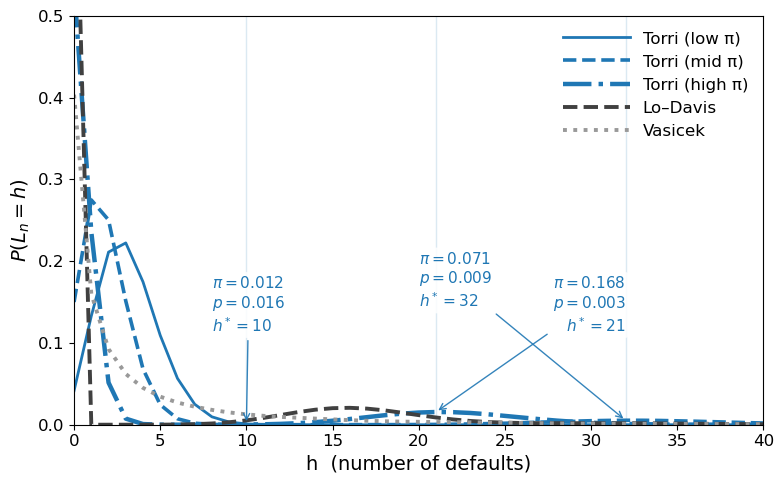

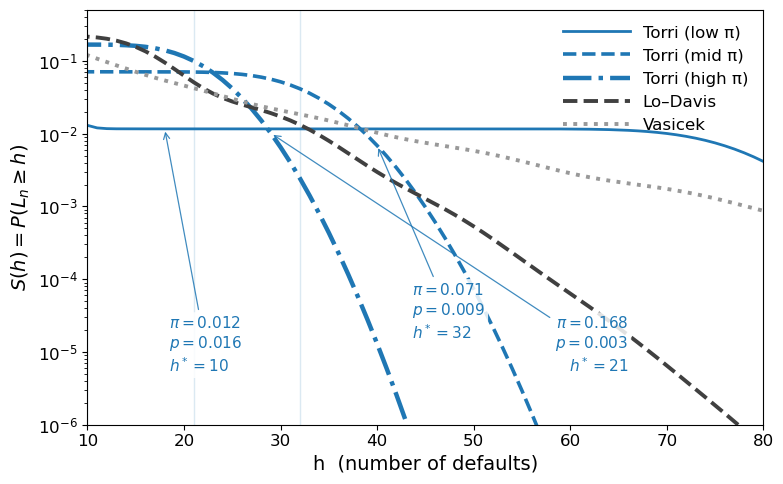

In [ ]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# =========================
# Paper-ready style
# =========================
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# =========================
# Helpers
# =========================
def systemic_prob_torri(n, p, v):
    # π = P(I_C^{(n)} = 1) = 1 - (1 - p v)^n
    return 1.0 - (1.0 - p * v) ** n

def high_h_peak(pmf, h0=10):
    """
    Find the peak location in the 'high-h' region (h>=h0).
    Returns (h_peak, y_peak).
    """
    h0 = int(h0)
    h0 = min(max(h0, 0), len(pmf)-1)
    h_peak = h0 + int(np.argmax(pmf[h0:]))
    return h_peak, float(pmf[h_peak])

def survival_from_pmf_safe(pmf, eps=1e-300):
    S = survival_from_pmf(pmf)
    return np.maximum(S, eps)

def select_three_by_pi(sols_Torri, n):
    """
    Select 3 representative Torri solutions by π:
    low (min), mid (median), high (max).
    Returns [(pi_low,d_low), (pi_mid,d_mid), (pi_high,d_high)] sorted by pi.
    """
    torri = [(systemic_prob_torri(n, d["p"], d["v"]), d) for d in sols_Torri]
    torri.sort(key=lambda t: t[0])
    if len(torri) == 0:
        raise ValueError("sols_Torri is empty.")

    idxs = [0, len(torri)//2, len(torri)-1]
    rep = [torri[i] for i in idxs]
    rep.sort(key=lambda t: t[0])  # ensure low < mid < high
    return rep

# =========================
# Choose representative Torri curves
# =========================
rep_T = select_three_by_pi(sols_Torri, n)  # [(pi,d_low),(pi,d_mid),(pi,d_high)]

# --- OPTIONAL ---
# If you want p shown in annotation text, set True.
INCLUDE_P_IN_ANNOT = True

labels_T = [
    "Torri (low π)",
    "Torri (mid π)",
    "Torri (high π)"
]


# same color family, but distinguish by line/marker
torri_styles = [
    dict(color="tab:blue", linestyle="-",  linewidth=2.0, marker="", markevery=5, ms=8,
         markeredgecolor="white", markeredgewidth=0.8),
    dict(color="tab:blue", linestyle="--", linewidth=2.6, marker="", markevery=5, ms=8,
         markeredgecolor="white", markeredgewidth=0.8),
    dict(color="tab:blue", linestyle="-.",  linewidth=3.2, marker="", markevery=5, ms=8,
         markeredgecolor="white", markeredgewidth=0.8),
]


# ---- Annotation slots (axes fraction): adjust ONCE and you are done ----
ann_pos_pmf  = [(0.20, 0.22), (0.50, 0.28), (0.80, 0.22)]
ann_pos_surv = [(0.12, 0.12), (0.48, 0.20), (0.80, 0.12)]

# Arrow shortening for survival to avoid crossing
SURV_ARROW_SHIFT = 8  # move arrow target to the right by this many h steps

# Axis ranges (edit if you like)
PMF_XMAX = 40
PMF_YMAX = 0.5

SURV_XMIN = 10
SURV_XMAX = min(n, 80)
SURV_YMIN = 1e-6
SURV_YMAX = 0.5

# Shared x-grid
x = np.arange(n + 1)

def torri_annot_text(pi, d, h_peak):
    if INCLUDE_P_IN_ANNOT:
        return rf"$\pi={pi:.3f}$" + "\n" + rf"$p={d['p']:.3f}$" + "\n" + rf"$h^*={h_peak}$"
    else:
        return rf"$\pi={pi:.3f}$" + "\n" + rf"$h^*={h_peak}$"

# =========================
# 1) PMF plot
# =========================
plt.figure(figsize=(8.0, 5.0))

for (pi, d), lab, sty, (tx, ty) in zip(rep_T, labels_T, torri_styles, ann_pos_pmf):
    pmf = pmf_Torri(n, d["p"], d["u"], d["v"])

    plt.plot(
        x, pmf,
        label=lab,
        **sty
    )

    # mark high-h peak in PMF
    h_peak, y_peak = high_h_peak(pmf, h0=10)
    plt.axvline(h_peak, color=sty["color"], alpha=0.16, linewidth=1.0)

    ha = "right" if tx > 0.65 else "left"
    plt.annotate(
        torri_annot_text(pi, d, h_peak),
        xy=(h_peak, y_peak), xycoords="data",
        xytext=(tx, ty), textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=1.0, color=sty["color"], alpha=0.9),
        fontsize=11,
        fontweight="bold",
        color=sty["color"],
        ha=ha, va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
    )

# Lo–Davis & Vasicek
plt.plot(x, pmf_ld, linestyle="--", linewidth=2.8, color="0.25", label="Lo–Davis")
plt.plot(x, pmf_vas, linestyle=":",  linewidth=2.8, color="0.60", label="Vasicek")

plt.xlim(0, PMF_XMAX)
plt.ylim(0, PMF_YMAX)
plt.xlabel("h  (number of defaults)")
plt.ylabel(r"$P(L_n = h)$")
plt.legend(
    frameon=False,
    loc="upper right",
    handlelength=4
)
plt.tight_layout()
plt.savefig("figure1a_pmf.pdf", bbox_inches="tight")
plt.show()


# =========================
# 2) Survival (right tail) plot
# =========================
plt.figure(figsize=(8.0, 5.0))
eps = 1e-300

for (pi, d), lab, sty, (tx, ty) in zip(rep_T, labels_T, torri_styles, ann_pos_surv):
    pmf = pmf_Torri(n, d["p"], d["u"], d["v"])
    S = np.maximum(survival_from_pmf(pmf), eps)

    plt.plot(
        x, S,
        label=lab,
        **sty
    )

    # systemic-mode marker: use PMF high-h peak
    h_peak, _ = high_h_peak(pmf, h0=10)
    plt.axvline(h_peak, color=sty["color"], alpha=0.16, linewidth=1.0)

    # arrow target slightly to the right to reduce crossings
    h_arrow = min(h_peak + SURV_ARROW_SHIFT, SURV_XMAX)
    y_arrow = float(S[h_arrow])

    ha = "right" if tx > 0.65 else "left"

    plt.annotate(
        torri_annot_text(pi, d, h_peak),
        xy=(h_arrow, y_arrow), xycoords="data",
        xytext=(tx, ty), textcoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=0.9, color=sty["color"], alpha=0.85),
        fontsize=11,
        fontweight="bold",
        color=sty["color"],
        ha=ha, va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
        zorder=10
    )

# ---- Lo–Davis & Vasicek ----
S_LD = np.maximum(survival_from_pmf(pmf_ld), eps)
S_VA = np.maximum(survival_from_pmf(pmf_vas), eps)

plt.plot(x, S_LD, linestyle="--", linewidth=2.8, color="0.25", label="Lo–Davis")
plt.plot(x, S_VA, linestyle=":",  linewidth=2.8, color="0.60", label="Vasicek")

plt.yscale("log")
plt.xlim(SURV_XMIN, SURV_XMAX)
plt.ylim(SURV_YMIN, SURV_YMAX)

plt.xlabel("h  (number of defaults)")
plt.ylabel(r"$S(h)=P(L_n \geq h)$")
plt.legend(
    frameon=False,
    loc="upper right",
    handlelength=4
)
plt.tight_layout()
plt.savefig("figure1b_tail.pdf", bbox_inches="tight")
plt.show()

## Notes

This section compares distributional shapes and right-tail behavior under matched first and second moments.

## Activation probability

Illustration of how the Torri activation probability varies along the iso-*(m, rho)* manifold.

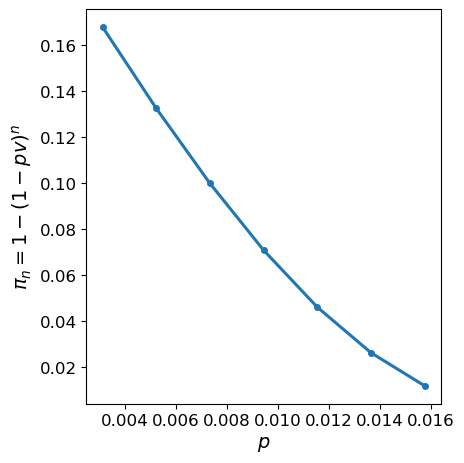

In [13]:
# -------------------------
# π(p) plot for Torri on iso-(m, rho)
#   π = P(I_C^{(n)}=1) = 1 - (1 - p v)^n
# -------------------------
import matplotlib as mpl
mpl.rcParams["text.usetex"] = False

mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})


def pi_torri(n, p, v):
    return 1.0 - (1.0 - p * v) ** n

# sols_Torri: list of dicts like {"p":..., "u":..., "v":...}
ps = np.array([d["p"] for d in sols_Torri], dtype=float)
vs = np.array([d["v"] for d in sols_Torri], dtype=float)
pis = pi_torri(n, ps, vs)

# sort by p for a clean curve
order = np.argsort(ps)
ps_s = ps[order]
pis_s = pis[order]


plt.figure(figsize=(4.8, 4.8))
plt.plot(ps_s, pis_s, marker="o", markersize=4)

plt.xlabel(r"$p$")
plt.ylabel(r"$\pi_n = 1 - (1 - p v)^n$")

plt.tight_layout()
plt.savefig("figure6a_pi_vs_p.pdf", bbox_inches="tight")
plt.show()


## Tail-risk comparison

Compute VaR and ES across Torri solutions, with Lo–Davis and Vasicek as references.

In [14]:
# =========================
# Settings
# =========================
alpha = 0.99
strict_es = False  # True -> E[L | L > VaR], False -> E[L | L >= VaR]

# =========================
# Paper style
# =========================
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
})

# =========================
# Build one table (compute ONCE)
# =========================
rows = []

# --- Torri ---
for d in sols_Torri:
    p_t = float(d["p"])
    u_t = float(d["u"])
    v_t = float(d["v"])
    pi_n = 1.0 - (1.0 - p_t * v_t) ** n

    pmf = pmf_Torri(n, p_t, u_t, v_t)
    met = tail_metrics_from_pmf(pmf, alpha=alpha, strict_es=strict_es)

    rows.append({
        "Model": "Torri",
        "p": p_t,
        "u": u_t,
        "v": v_t,
        "pi_n": pi_n,
        "VaR_99": float(met["VaR"]),
        "ES_99": float(met["ES"]),
        "ES_minus_VaR": float(met["ES_minus_VaR"]),
        "ES_div_VaR": float(met["ES_over_VaR"]),
    })

# --- LD ---
met_ld = tail_metrics_from_pmf(pmf_ld, alpha=alpha, strict_es=strict_es)
rows.append({
    "Model": "LD",
    "p": float(sol_LD["p"]) if ("sol_LD" in globals() and sol_LD is not None and "p" in sol_LD) else np.nan,
    "u": np.nan,
    "v": np.nan,
    "pi_n": np.nan,
    "VaR_99": float(met_ld["VaR"]),
    "ES_99": float(met_ld["ES"]),
    "ES_minus_VaR": float(met_ld["ES_minus_VaR"]),
    "ES_div_VaR": float(met_ld["ES_over_VaR"]),
})

# --- Vasicek ---
met_vas = tail_metrics_from_pmf(pmf_vas, alpha=alpha, strict_es=strict_es)
rows.append({
    "Model": "Vasicek",
    "p": float(m_target) if ("m_target" in globals()) else np.nan,
    "u": np.nan,
    "v": np.nan,
    "pi_n": np.nan,
    "VaR_99": float(met_vas["VaR"]),
    "ES_99": float(met_vas["ES"]),
    "ES_minus_VaR": float(met_vas["ES_minus_VaR"]),
    "ES_div_VaR": float(met_vas["ES_over_VaR"]),
})

df = pd.DataFrame(rows)[
    ["Model", "p", "u", "v", "pi_n", "VaR_99", "ES_99", "ES_minus_VaR", "ES_div_VaR"]
]

# order: Torri(sorted by pi_n), LD, Vasicek
df = pd.concat([
    df[df["Model"] == "Torri"].sort_values("pi_n"),
    df[df["Model"] == "LD"],
    df[df["Model"] == "Vasicek"],
], ignore_index=True)

print(df)
df.to_csv("tail_metrics_vs_pi_table.csv", index=False)
print("\nSaved: tail_metrics_vs_pi_table.csv")



     Model         p         u         v      pi_n  VaR_99      ES_99  \
0    Torri  0.015762  0.627897  0.003710  0.011629    70.0  78.737869   
1    Torri  0.013653  0.751775  0.009666  0.026051    54.0  58.132238   
2    Torri  0.011544  0.812739  0.020350  0.045905    44.0  47.075229   
3    Torri  0.009436  0.848454  0.038857  0.070716    38.0  40.468458   
4    Torri  0.007327  0.871519  0.071763  0.099841    34.0  36.073926   
5    Torri  0.005218  0.887343  0.136180  0.132519    31.0  32.817221   
6    Torri  0.003109  0.898636  0.295516  0.167923    29.0  30.591544   
7       LD  0.001246       NaN       NaN       NaN    33.0  37.915131   
8  Vasicek  0.020000       NaN       NaN       NaN    40.0  55.815995   

   ES_minus_VaR  ES_div_VaR  
0      8.737869    1.124827  
1      4.132238    1.076523  
2      3.075229    1.069892  
3      2.468458    1.064959  
4      2.073926    1.060998  
5      1.817221    1.058620  
6      1.591544    1.054881  
7      4.915131    1.148943  

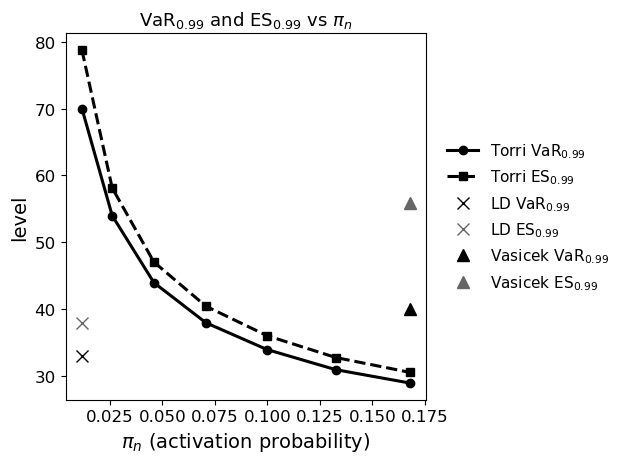

In [15]:
# =========================
# Plot from df (no recomputation)
# =========================
dfT = df[df["Model"]=="Torri"].copy()
ps   = dfT["p"].to_numpy(float)
varT = dfT["VaR_99"].to_numpy(float)
esT  = dfT["ES_99"].to_numpy(float)
tmeT = dfT["ES_minus_VaR"].to_numpy(float)

var_ld, es_ld, tme_ld = df.loc[df["Model"]=="LD", ["VaR_99","ES_99","ES_minus_VaR"]].iloc[0].astype(float)
var_vas, es_vas, tme_vas = df.loc[df["Model"]=="Vasicek", ["VaR_99","ES_99","ES_minus_VaR"]].iloc[0].astype(float)

# =========================
# Compute π_n for Torri
# =========================
pis = 1.0 - (1.0 - dfT["p"].to_numpy(float) * dfT["v"].to_numpy(float))**n

# =========================
# Sort by π (見やすさのため)
# =========================
order = np.argsort(pis)
pis  = pis[order]
varT = varT[order]
esT  = esT[order]
tmeT = tmeT[order]

# =========================
# Figure 1: VaR & ES vs π
# =========================
fig2, ax = plt.subplots(figsize=(7.6, 4.8))

# Torri
ax.plot(pis, varT, marker="o", linestyle="-",  color="black",
        label=r"Torri $\mathrm{VaR}_{0.99}$")

ax.plot(pis, esT,  marker="s", linestyle="--", color="black",
        label=r"Torri $\mathrm{ES}_{0.99}$")

# LD（単一点）
ax.plot(pis[0], var_ld, marker="x", color="black", linestyle="None", markersize=9,
        label=r"LD $\mathrm{VaR}_{0.99}$")
ax.plot(pis[0], es_ld,  marker="x", color="0.4", linestyle="None", markersize=9,
        label=r"LD $\mathrm{ES}_{0.99}$")

# Vasicek（単一点）
ax.plot(pis[-1], var_vas, marker="^", color="black", linestyle="None", markersize=8,
        label=r"Vasicek $\mathrm{VaR}_{0.99}$")
ax.plot(pis[-1], es_vas,  marker="^", color="0.4", linestyle="None", markersize=8,
        label=r"Vasicek $\mathrm{ES}_{0.99}$")

ax.set_xlabel(r"$\pi_n$ (activation probability)")
ax.set_ylabel("level")
ax.set_title(r"$\mathrm{VaR}_{0.99}$ and $\mathrm{ES}_{0.99}$ vs $\pi_n$")

ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig2.tight_layout(rect=[0, 0, 0.85, 1])
fig2.savefig("figure6b_var_es_vs_pi_appendix.pdf", bbox_inches="tight")
plt.show()
